# Imports

Import all required Python libraries for data handling, visualization, preprocessing, modeling, and evaluation.
This section sets up the tools needed for the complete machine learning workflow.

Import the libraries needed for data analysis, visualization, preprocessing, model training, and evaluation.


In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error , r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

Explore the dataset to understand its shape, columns, missing values, duplicates, and basic statistics.
Use visualizations and summaries to find patterns, relationships, and possible outliers in the data.

Load the housing dataset and display a random sample of rows.


In [116]:
df = pd.read_csv("../Housing.csv")
df.sample(5)#this shows random rows

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
95,6300000,4100,3,2,3,yes,no,no,no,yes,2,no,semi-furnished
369,3675000,3600,2,1,1,yes,no,no,no,no,0,no,furnished
462,3080000,2160,3,1,2,no,no,yes,no,no,0,no,semi-furnished
506,2604000,2910,2,1,1,no,no,no,no,no,0,no,unfurnished
493,2800000,3960,3,1,1,yes,no,no,no,no,0,no,furnished


Check column names, data types, and non-null counts.


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


View summary statistics for the numerical columns.


In [118]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


Check whether the dataset contains duplicate rows.


In [119]:
df.duplicated().any()

np.False_

Display all column names in the dataset.


In [120]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

Show the number of rows and columns in the dataset.


In [121]:
df.shape

(545, 13)

Count missing values in each column.


In [122]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

# Plots

Create visualizations to understand relationships between important house features and price.
Use plots to compare numeric trends and categorical differences before preprocessing the data.

Calculate correlations between numeric features and house price.


In [123]:
#this is for showing which columns affect the price most
correlation = df.corr(numeric_only= True)["price"].sort_values(ascending=False)
correlation

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

Plot numeric feature relationships with price using regression plots.


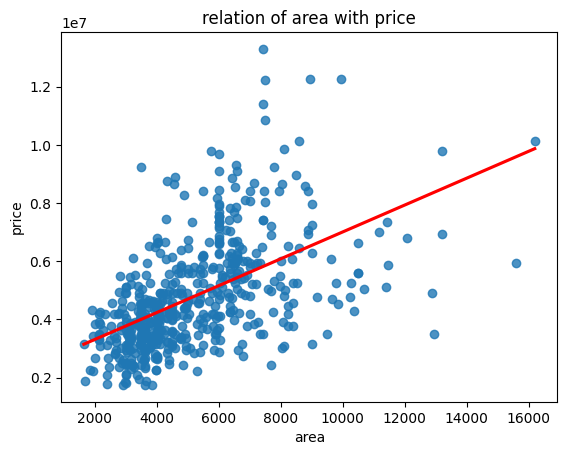

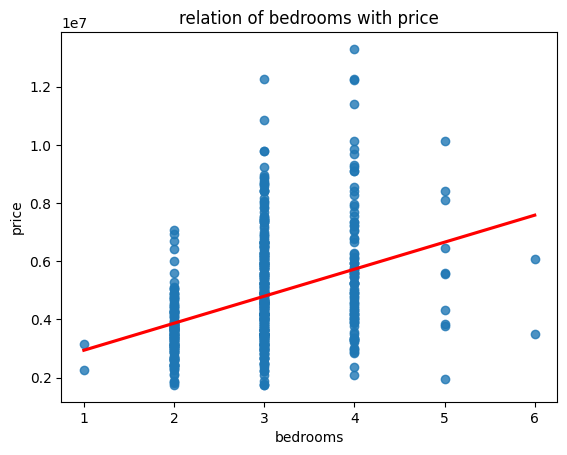

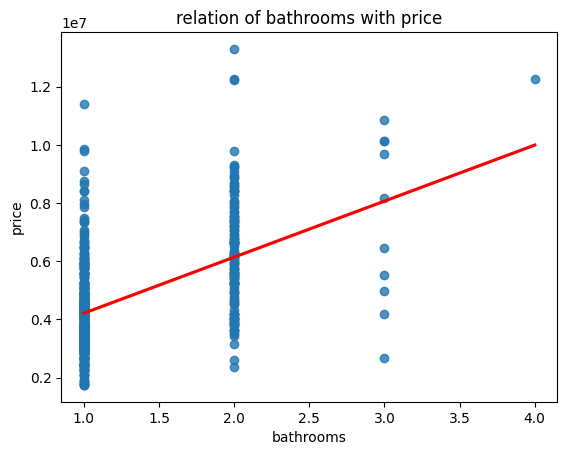

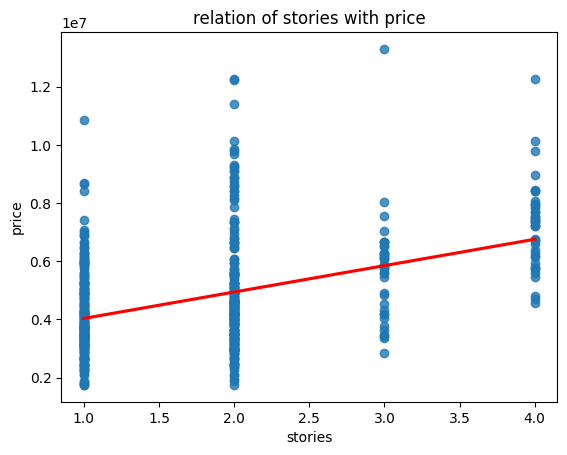

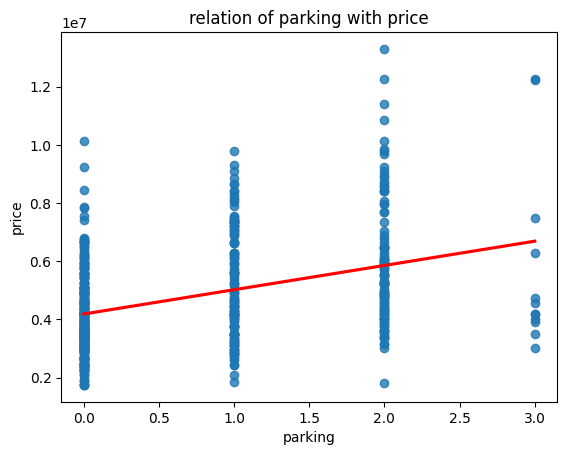

In [124]:
# this is for scatter plots
numerical_columns = df.select_dtypes(include=["int64", "float64"])
for col in numerical_columns:
    if col != "price":
        sns.regplot(
            x = col,
            y = "price",
            data = df,
            ci=None,
            line_kws={"color" : "red"}
        )
        plt.title(f"relation of {col} with price")
        plt.xlabel(col)
        plt.ylabel("price")
        plt.show()

Visualize how area and furnishing status relate to house price.


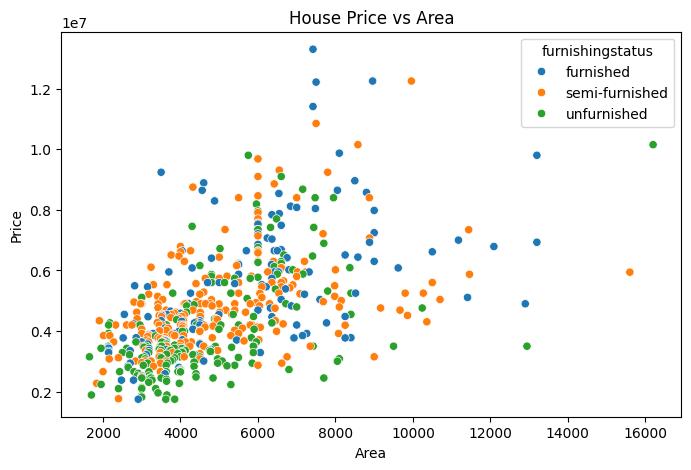

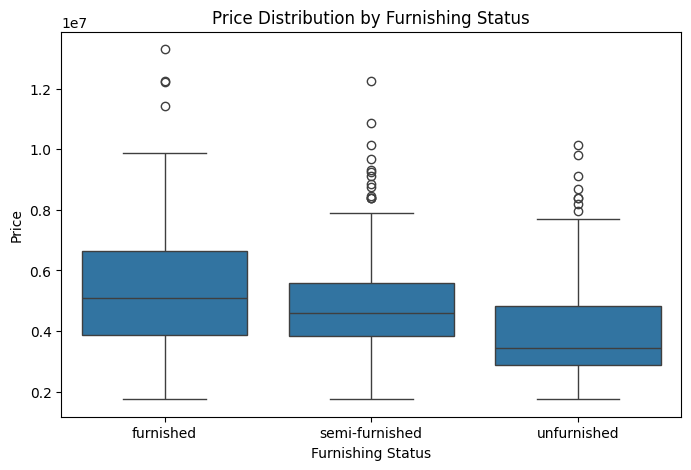

In [125]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="area", y="price", hue="furnishingstatus")
plt.title("House Price vs Area")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="furnishingstatus", y="price")
plt.title("Price Distribution by Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Price")
plt.show()

# Preprocessing

Prepare the data for machine learning by handling categorical values, missing values, and feature scaling if needed.
Split the dataset into input features and target values, then create training and testing sets.

Separate input features from the target and split the data into train and test sets.


In [126]:
x = df.drop(columns = ["price"])#all features reside here
y = df["price"]#the outcome resides here
X_train , X_test , Y_train , Y_test = train_test_split(x,y , test_size=0.2,random_state = 42)#splitting the

Identify numerical and categorical feature columns for preprocessing.


In [127]:
numerical_columns = x.select_dtypes(include = ["int64" , "float64"]).columns#creating numerical columns
categorical_columns = x.select_dtypes(include = "object").columns#creating categorical columns

Build a preprocessing transformer for imputation, encoding, and scaling.


In [128]:
#one hot encoding #try to add simple imputer even if it doesnt contain missing values
simple_imputer = SimpleImputer()
standard_scaler = StandardScaler()
preprocessor  = ColumnTransformer(transformers=[
    ("simple_imputer" ,simple_imputer, numerical_columns),
    ("one_hot_encoding" , OneHotEncoder(sparse_output = False , handle_unknown= "ignore"), categorical_columns),
    ("StandardScaler" , standard_scaler , numerical_columns)
])

Create the Linear Regression model and combine it with preprocessing in a pipeline.


In [129]:
transformer2 = LinearRegression()#creating the object
pipe = make_pipeline(preprocessor, transformer2)#creating the pipeline
#preprocessor contains  one hot encoding and scaling and simple imputer even though it doesnot contain 
#any missing values

# Training model

Train the machine learning model or pipeline using the prepared training data.
This section fits the model so it can learn the relationship between house features and price.

Train the full pipeline on the training data.


In [130]:
pipe.fit(X_train , Y_train)#training the pipeline which contains model

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('simple_imputer', ...), ('one_hot_encoding', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Display the preprocessing and model steps inside the pipeline.


In [131]:
pipe.named_steps#this shows all the steps included in pipeline


{'columntransformer': ColumnTransformer(transformers=[('simple_imputer', SimpleImputer(),
                                  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')),
                                 ('one_hot_encoding',
                                  OneHotEncoder(handle_unknown='ignore',
                                                sparse_output=False),
                                  Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
        'airconditioning', 'prefarea', 'furnishingstatus'],
       dtype='object')),
                                 ('StandardScaler', StandardScaler(),
                                  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object'))]),
 'linearregression': LinearRegression()}

# Evaluation

Evaluate the trained model using the test data and compare predicted prices with actual prices.
Use regression metrics such as MAE, MSE, RMSE, and R2 score to measure model performance.

In [132]:
Y_pred = pipe.predict(X_test)#predicting the data

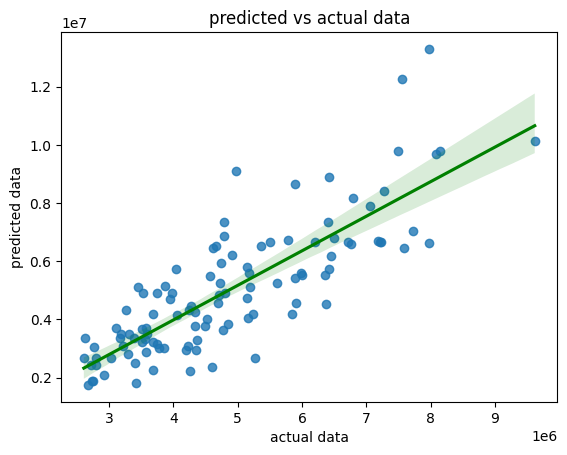

In [133]:
sns.regplot(
    x = Y_pred,
    y = Y_test,
    line_kws={"color":"green"}
)
plt.title("predicted vs actual data")
plt.xlabel("actual data")
plt.ylabel("predicted data")
ci = None
plt.show()


In [134]:
r2 = r2_score(Y_pred, Y_test)
r2

0.272644338062598

In [135]:
mse = mean_squared_error(Y_test , Y_pred)
mse

1754318687330.6348